# Materials Atlas — Crystal Structures: Geometry from Bonding

**How atoms arrange themselves into solids.** This notebook treats crystal structures as repeating geometric solutions to bonding and energy minimization—not as a catalogue to memorize.

- **Estimated duration:** 2.5–3 hours
- **Prerequisites:** `00-python-environment.ipynb`, `01-linear-algebra.ipynb`, `02-atomic-bonding.ipynb`
- **Required packages:** NumPy, Matplotlib

> Nearly every atomistic computation begins with a structure. The purpose here is to see why that structure exists and how to describe it clearly.

## Learning objectives

By the end, you will be able to explain why crystals form; distinguish crystalline and amorphous order; separate a lattice from its basis; use the unit-cell idea; identify SC, BCC, FCC, and HCP structures; reason about coordination and packing; estimate density from unit-cell geometry; visualize simple directions and planes; and explain why orientation affects properties.

## 1. Why do crystals form?

Atoms interact through the energy landscapes introduced in atomic bonding. When many atoms can repeat a low-energy neighborhood, a periodic arrangement can lower the total energy efficiently. Symmetry and repetition are therefore not decorative features: they are economical geometric solutions to many similar bonding constraints.

A **crystal** has long-range order: the arrangement remains predictable over many atomic spacings. A glass has local neighbor preferences too, but lacks that long-range repetition. Neither is “better”; each can be favored by composition, temperature, and processing history.

### Materials Atlas Connection

Crystal structures become inputs to electronic-structure calculations, DFT, molecular dynamics, diffraction interpretation, defect models, and materials-informatics descriptors. Structure is the shared starting language.

## 2. Order versus disorder

### Physical intuition

Gas particles have little positional order. Liquids retain short-range order—near neighbors exist—but continually rearrange. Amorphous solids freeze local neighborhoods without a repeating global pattern. Crystals preserve both local and long-range order.

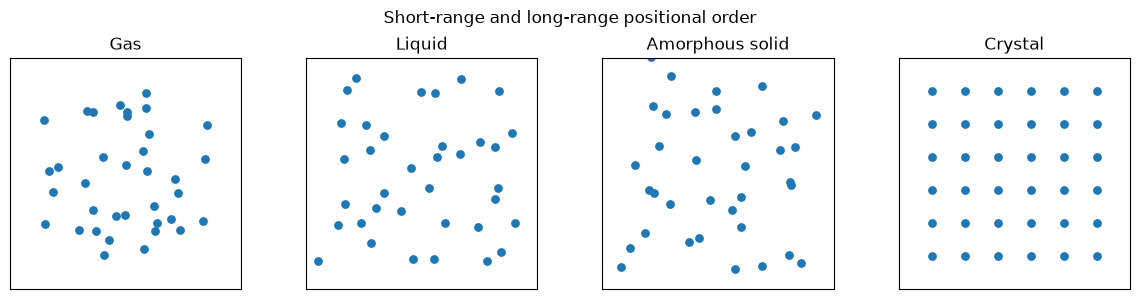

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

crystal_x, crystal_y = np.meshgrid(np.arange(6), np.arange(6))
crystal = np.column_stack((crystal_x.ravel(), crystal_y.ravel()))
gas = rng.uniform(0, 5, size=(36, 2))
liquid = crystal + rng.normal(scale=0.32, size=crystal.shape)
amorphous = crystal + rng.normal(scale=0.55, size=crystal.shape)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (name, points) in zip(axes, [("Gas", gas), ("Liquid", liquid), ("Amorphous solid", amorphous), ("Crystal", crystal)]):
    ax.scatter(points[:, 0], points[:, 1], s=28)
    ax.set(title=name, xlim=(-1, 6), ylim=(-1, 6))
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Short-range and long-range positional order")
fig.tight_layout()
plt.show()

### Reflection

Which panels retain recognizable nearby spacing? Which would let you predict an atom's location far away from a starting point?

### Materials Atlas Connection

Diffraction detects long-range periodicity. Molecular dynamics can model crystals, liquids, and glasses by changing temperature and allowing atoms to rearrange.

## 3. Lattice versus basis

### Geometry first

A **lattice** is an infinite set of equivalent points made by translating a pattern. A **basis** (or motif) is the atom or small group of atoms attached to every lattice point. Lattice plus basis gives a crystal structure.

This distinction is powerful: the same lattice can host different bases, and the same local motif can repeat on different lattices. Start in 2D so the separation is visible before thinking in 3D.

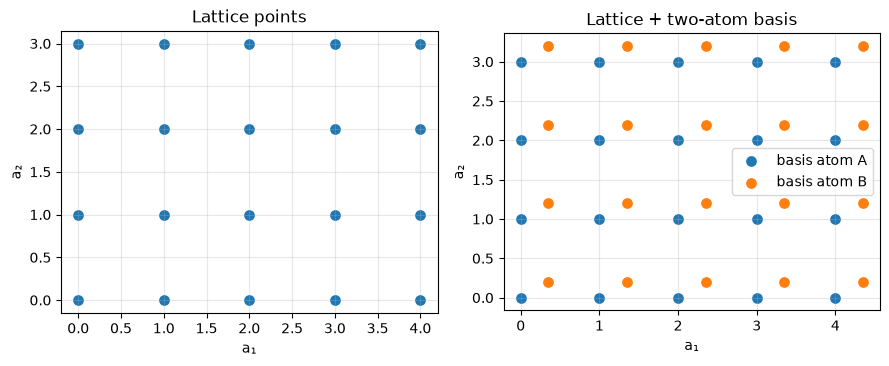

In [2]:
ix, iy = np.meshgrid(np.arange(5), np.arange(4))
lattice = np.column_stack((ix.ravel(), iy.ravel()))
basis_offset = np.array([0.35, 0.20])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].scatter(lattice[:, 0], lattice[:, 1], s=45)
axes[0].set(title="Lattice points", xlabel="a₁", ylabel="a₂")
axes[1].scatter(lattice[:, 0], lattice[:, 1], s=45, label="basis atom A")
axes[1].scatter(lattice[:, 0] + basis_offset[0], lattice[:, 1] + basis_offset[1], s=45, label="basis atom B")
axes[1].set(title="Lattice + two-atom basis", xlabel="a₁", ylabel="a₂")
for ax in axes:
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
plt.show()

### Mathematics

In any dimension, a lattice point can be written as $\mathbf{R}=n_1\mathbf{a}_1+n_2\mathbf{a}_2+n_3\mathbf{a}_3$, where the $n_i$ are integers and the $\mathbf{a}_i$ are translation vectors. Your linear-algebra tools are already doing crystallography.

### Experiment

Change `basis_offset`. What changes in the crystal: its lattice, its basis, or both?

### Materials Atlas Connection

DFT input files, crystallographic databases, and pymatgen all use this lattice-plus-basis representation.

## 4. Unit cells

A **unit cell** is a small region that tiles space by translation. A **primitive cell** contains exactly one lattice point's worth of space. A **conventional cell** may be larger, chosen because its symmetry makes the structure easier to see. Neither is more physically real; they are coordinate choices for describing an infinite arrangement.

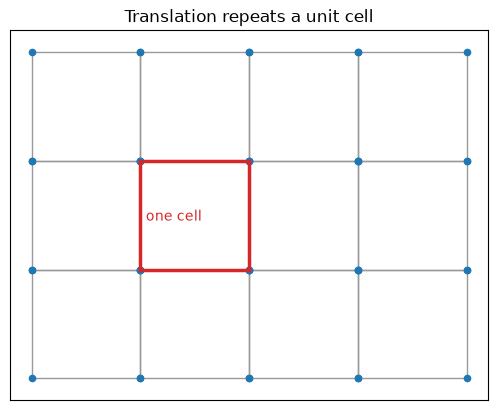

In [3]:
fig, ax = plt.subplots()
for i in range(4):
    for j in range(3):
        ax.add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor="0.6"))
        ax.scatter([i, i + 1, i, i + 1], [j, j, j + 1, j + 1], color="tab:blue", s=20)
ax.add_patch(plt.Rectangle((1, 1), 1, 1, fill=False, edgecolor="tab:red", linewidth=2.5))
ax.text(1.05, 1.45, "one cell", color="tab:red")
ax.set(aspect="equal", xlim=(-0.2, 4.2), ylim=(-0.2, 3.2), title="Translation repeats a unit cell")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

### Reflection

Why can a small drawing represent a macroscopic crystal? Why might a larger conventional cell be more useful for communication?

### Materials Atlas Connection

Simulation cells in molecular dynamics and periodic boundary conditions in DFT are computational versions of this repetition idea.

## 5. Crystal systems

Only after the repetition idea is clear do names help. The seven crystal systems—cubic, tetragonal, orthorhombic, hexagonal, trigonal, monoclinic, and triclinic—group possible lattice geometries by their translation lengths and angles. Treat them as a compact classification of symmetry constraints, not a list to recite.

We will focus on cubic structures and HCP because their geometry makes coordination, packing, and property differences especially visible.

## 6. Cubic structures: SC, BCC, and FCC

### Geometry

**Simple cubic (SC)** has atoms at cube corners. **Body-centered cubic (BCC)** adds one at the cube center. **Face-centered cubic (FCC)** adds atoms at every face center. Corner atoms are shared among eight neighboring cells; face atoms are shared between two. These sharing rules explain atom counts per cell.

The structures differ in how many nearest neighbors each atom sees—its **coordination number**—and how efficiently equal-sized atoms fill space. The drawings use the hard-sphere model: nearest-neighbor spheres touch, a convenient geometric approximation rather than a literal picture of electron clouds. That contact gives useful radius relationships: SC has $a=2R$, BCC has $a=4R/\sqrt{3}$ along its body diagonal, and FCC has $a=2\sqrt{2}R$ along a face diagonal.

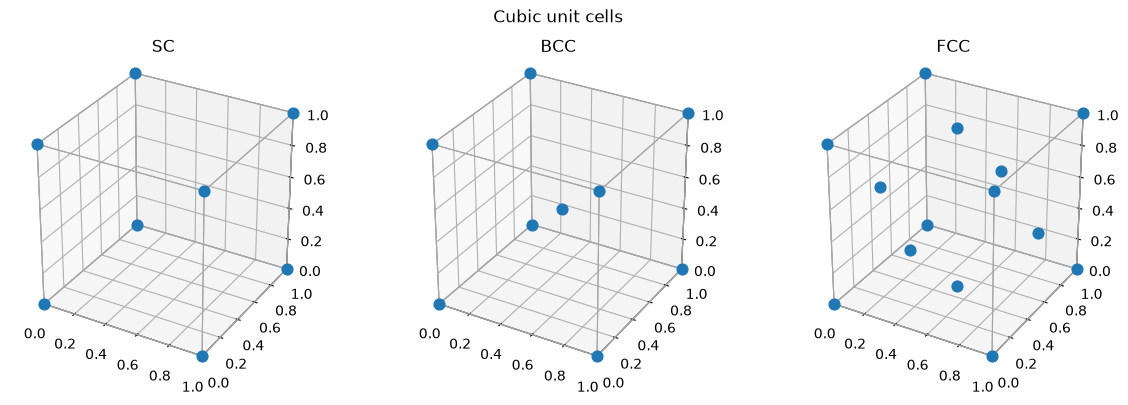

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # enables 3D projection in Matplotlib

corners = np.array([[x, y, z] for x in (0, 1) for y in (0, 1) for z in (0, 1)])
structures = {
    "SC": corners,
    "BCC": np.vstack((corners, [[0.5, 0.5, 0.5]])),
    "FCC": np.vstack((corners, [[0.5, 0.5, 0], [0.5, 0.5, 1], [0.5, 0, 0.5], [0.5, 1, 0.5], [0, 0.5, 0.5], [1, 0.5, 0.5]])),
}

def draw_cube(ax, points, title):
    edges = [(a, b) for a in corners for b in corners if np.sum(np.abs(a - b)) == 1]
    for a, b in edges:
        ax.plot(*zip(a, b), color="0.65", linewidth=0.8)
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=60, depthshade=False)
    ax.set(title=title, xlim=(0, 1), ylim=(0, 1), zlim=(0, 1))
    ax.set_box_aspect((1, 1, 1))

fig = plt.figure(figsize=(12, 3.8))
for index, (name, points) in enumerate(structures.items(), start=1):
    draw_cube(fig.add_subplot(1, 3, index, projection="3d"), points, name)
fig.suptitle("Cubic unit cells")
fig.tight_layout()
plt.show()

| Structure | Atoms per conventional cell | Coordination number | Atomic packing factor | Examples and implications |
| --- | ---: | ---: | ---: | --- |
| SC | 1 | 6 | 0.52 | Polonium; open structure, rare for elemental metals |
| BCC | 2 | 8 | 0.68 | Iron at room temperature, tungsten; not close-packed |
| FCC | 4 | 12 | 0.74 | Aluminum, copper, nickel; close-packed and often ductile |

The packing factor is the fraction of cell volume occupied by ideal hard spheres. It is a geometric comparison, not a complete theory of density or strength.

### Experiment

Rotate the 3D panels with the notebook toolbar. Can you identify the BCC center atom and the FCC face atoms? Why does adding atoms change coordination without necessarily changing the outer cube?

### Materials Atlas Connection

Crystal structure affects slip systems, diffusion paths, elastic response, electronic bands, and the starting geometry of atomistic calculations.

## 7. Hexagonal close packed (HCP)

HCP and FCC are both close-packed: each atom has 12 nearest neighbors and the same ideal packing factor, 0.74. Their difference is stacking sequence. FCC layers stack **ABCABC...**; HCP layers stack **ABAB...**. Similar local packing does not mean identical symmetry or deformation behavior.

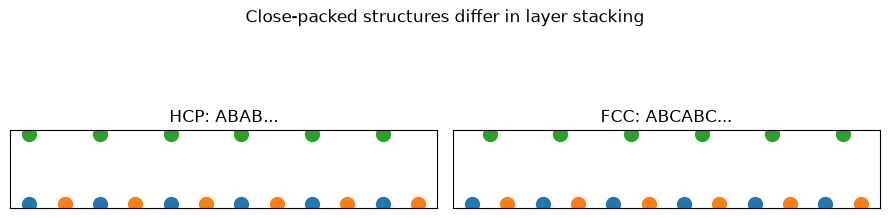

In [5]:
x = np.arange(6)
layer_a = np.column_stack((x, np.zeros_like(x)))
layer_b = np.column_stack((x + 0.5, np.full_like(x, np.sqrt(3) / 2)))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, labels in zip(axes, [("A", "B", "A"), ("A", "B", "C")]):
    for row, label in enumerate(labels):
        offset = 0 if label == "A" else (0.5 if label == "B" else 0.25)
        ax.scatter(x + offset, np.full_like(x, row * 0.9), s=100, label=label if row == 0 else None)
    ax.set(title=("HCP: ABAB..." if labels[-1] == "A" else "FCC: ABCABC..."), aspect="equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Close-packed structures differ in layer stacking")
fig.tight_layout()
plt.show()

### Reflection

How can two structures have the same nearest-neighbor count and packing efficiency yet still have different properties?

### Materials Atlas Connection

HCP metals such as magnesium and titanium have fewer easily activated slip systems at room temperature than FCC metals; crystal geometry connects directly to plastic deformation.

## 8. Packing efficiency and density

### Intuition

Close-packed structures are common because they give each atom many favorable near neighbors while leaving less empty space. Packing is not the only energetic consideration—bond directionality and electron behavior can favor more open structures—but it is a useful geometric clue. Packing factor is not density: density also depends on atomic mass and the actual lattice parameter.

Density follows from mass per cell divided by cell volume: $\rho=nm/(a^3)$ for a cubic cell, where $n$ is atoms per cell, $m$ is mass per atom, and $a$ is lattice parameter.

In [6]:
atomic_mass_g_mol = 63.546  # copper
avogadro = 6.02214076e23
lattice_parameter_cm = 3.615e-8
atoms_per_fcc_cell = 4
mass_per_cell_g = atoms_per_fcc_cell * atomic_mass_g_mol / avogadro
volume_per_cell_cm3 = lattice_parameter_cm**3
density_g_cm3 = mass_per_cell_g / volume_per_cell_cm3
print(f"FCC copper density estimate: {density_g_cm3:.2f} g/cm³")
print("Reference value is approximately 8.96 g/cm³; small differences reflect rounding.")

FCC copper density estimate: 8.93 g/cm³
Reference value is approximately 8.96 g/cm³; small differences reflect rounding.


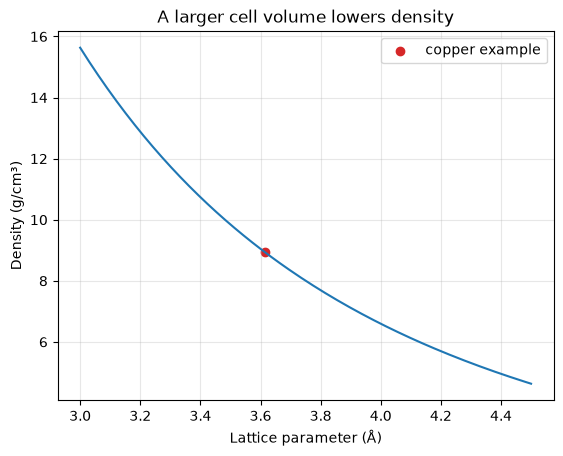

In [7]:
a_values = np.linspace(3.0, 4.5, 150) * 1e-8
density_values = mass_per_cell_g / a_values**3
fig, ax = plt.subplots()
ax.plot(a_values / 1e-8, density_values)
ax.scatter([3.615], [density_g_cm3], color="tab:red", label="copper example")
ax.set(xlabel="Lattice parameter (Å)", ylabel="Density (g/cm³)", title="A larger cell volume lowers density")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Experiment

Change the lattice parameter by 5%. Does density change by 5%? Use the $a^3$ relationship and the plot to explain the difference. Compare the atom counts for SC, BCC, and FCC while holding mass and `a` fixed.

### Materials Atlas Connection

Cell geometry and density appear in structure databases, diffraction refinements, equation-of-state calculations, and simulation setup.

## 9. Crystal directions and planes

### Geometry before notation

A direction is an arrow through a lattice, so it is a direct application of vectors. In cubic crystals, `[uvw]` records a direction in lattice-coordinate steps. A plane is a repeating sheet of atoms; Miller indices `(hkl)` label its orientation through reciprocal intercepts. The notation is a compact address, not the concept itself.

Directions and planes matter because bonds, slip, diffusion, and surfaces can differ by orientation.

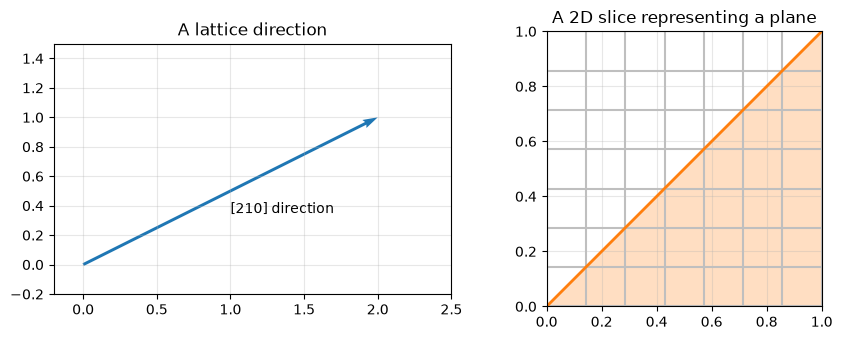

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].quiver(0, 0, 2, 1, angles="xy", scale_units="xy", scale=1, color="tab:blue")
axes[0].text(1.0, 0.35, "[210] direction")
axes[0].set(xlim=(-0.2, 2.5), ylim=(-0.2, 1.5), aspect="equal", title="A lattice direction")
for t in np.linspace(0, 1, 8):
    axes[1].plot([t, t], [0, 1], color="0.75")
    axes[1].plot([0, 1], [t, t], color="0.75")
axes[1].fill([0, 1, 1], [0, 0, 1], alpha=0.25, color="tab:orange")
axes[1].plot([0, 1], [0, 1], color="tab:orange", linewidth=2)
axes[1].set(aspect="equal", xlim=(0, 1), ylim=(0, 1), title="A 2D slice representing a plane")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Reflection

Why is it useful to describe an orientation independently of a particular atom? How does a direction vector connect back to linear algebra?

### Materials Atlas Connection

Plane orientations organize surfaces in DFT, diffraction peaks, slip systems in mechanics, and interfaces in phase-field simulations.

## 10. Anisotropy: orientation changes response

A crystal is ordered, so rotating it can change how its bonds align with an applied load, heat flow, or electric field. **Anisotropy** means a property depends on direction. Elasticity, conductivity, thermal expansion, and plastic deformation can all be anisotropic.

A polycrystal averages many grain orientations, often reducing directional behavior—but texture can preserve it. Geometry is therefore not merely a drawing convention; it changes measured performance.

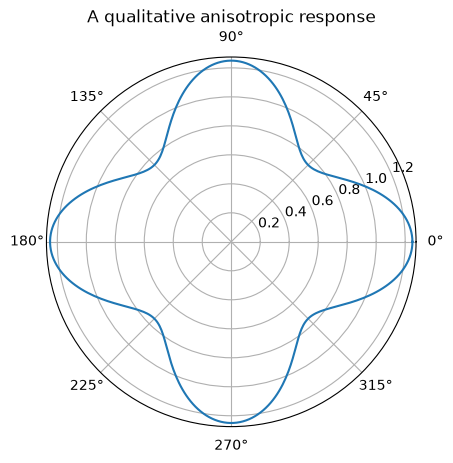

In [9]:
angle = np.linspace(0, 2 * np.pi, 360)
# A deliberately qualitative directional property, not a model of a specific crystal.
response = 1.0 + 0.25 * np.cos(4 * angle)
fig = plt.figure()
ax = fig.add_subplot(111, projection="polar")
ax.plot(angle, response)
ax.set(title="A qualitative anisotropic response")
plt.show()

### Materials Atlas Connection

Later modules use tensors to represent directional response, symmetry to constrain which tensor components are possible, and microstructure to understand how grains combine into engineering properties.

## 11. Computational materials science connections

```mermaid
flowchart LR

S[Crystal Structure]
P[Periodic Boundary Conditions]
B[Brillouin Zones]
M[Simulation Cells]
D[Diffraction]
G[Grain Evolution]
R[Crystal Descriptors]
N[Graph Representations]

S --> P
S --> B
S --> M
S --> D
S --> G
S --> R
R --> N
```

This diagram answers one question: **where does a crystal structure become computational input?** It is the starting object for electronic structure, atomistic simulation, diffraction, microstructure models, and data-driven representations.

- **Electronic structure and DFT:** periodic structures define unit cells, k-point sampling, and Brillouin zones.
- **Molecular dynamics:** a simulation cell repeats through periodic boundary conditions.
- **Diffraction:** a measured pattern is interpreted through periodic order.
- **Phase-field:** grains and interfaces evolve from crystallographic orientation.
- **Materials informatics and ML:** structures become descriptors or graphs used to predict properties.

## 12. Mini project — Crystal Structure Explorer

Use the next cell to compare SC, BCC, and FCC under a shared lattice parameter. The points are a single conventional cell; shared boundary atoms are displayed for geometry even though their atom count is fractional.

1. Choose a structure.
2. Change `lattice_parameter_angstrom`.
3. Compare its coordination number, packing factor, and ideal density.
4. Add a Markdown cell: what does the visual and numerical comparison reveal?

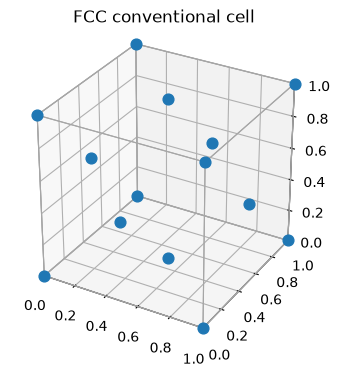

Coordination number: 12
Ideal packing factor: 0.74
Density estimate: 8.36 g/cm³


In [10]:
chosen_structure = "FCC"  # Try: SC, BCC, FCC
lattice_parameter_angstrom = 3.6
atomic_mass_g_mol = 58.6934  # nickel, used only for a comparable density estimate
properties = {
    "SC": {"atoms": 1, "coordination": 6, "packing": 0.52},
    "BCC": {"atoms": 2, "coordination": 8, "packing": 0.68},
    "FCC": {"atoms": 4, "coordination": 12, "packing": 0.74},
}
info = properties[chosen_structure]
a_cm = lattice_parameter_angstrom * 1e-8
explorer_density = (info["atoms"] * atomic_mass_g_mol / avogadro) / a_cm**3

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")
draw_cube(ax, structures[chosen_structure], f"{chosen_structure} conventional cell")
plt.show()
print(f"Coordination number: {info['coordination']}")
print(f"Ideal packing factor: {info['packing']:.2f}")
print(f"Density estimate: {explorer_density:.2f} g/cm³")

## 13. Reflection

1. Why do crystals repeat?
2. Why is every material not FCC?
3. Why does packing matter without fully determining properties?
4. Why is periodicity fundamental to computational materials science?
5. How does the lattice-plus-basis idea make a complex crystal more manageable?

Return to an earlier visualization if an answer feels abstract; spatial intuition is the goal.

## 14. Further exploration

This notebook's use of hard-sphere unit cells, coordination, packing, density, directions, planes, and anisotropy is aligned with Callister and Rethwisch, Chapter 3, *The Structure of Crystalline Solids*.


**Books:** William D. Callister Jr. and David G. Rethwisch, *Materials Science and Engineering*; Neil W. Ashcroft and N. David Mermin, *Solid State Physics*; Charles Kittel, *Introduction to Solid State Physics*.

**Software:** [ASE](../../resources/software/README.md#ase) for atomistic structures and simulations; [pymatgen](../../resources/software/README.md#pymatgen) for crystallographic analysis; VESTA for interactive crystal visualization.

**Atlas references:** [foundational diagrams](../../references/diagrams/foundations.md), [books](../../resources/books/README.md), and [software](../../resources/software/README.md).

## 15. Continue with

Continue to **[04-thermodynamics.ipynb](04-thermodynamics.ipynb)**. Crystal structure describes an arrangement; thermodynamics supplies the energy and entropy language for predicting which arrangement is stable under particular temperatures, pressures, and compositions.